In [47]:
from pathlib import Path
from tqdm import tqdm
tqdm.pandas()
#
import biotite.structure as struc
import biotite.structure.io as strucio
import hydride
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [48]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [49]:
# read in data
data = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/backbones.csv', index_col = 0)

#### Load data

In [3]:
# paths to data
original_path = '/wynton/home/rotation/geanhu/multi-state/data/string-sampling/end-states'
refined_path = '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE-5KPH/pdb'

In [4]:
# store df of all names
data = {
    'name': [],
}
for item in Path(original_path).iterdir():
    if str(item).endswith('.pdb'):
        data['name'].append(item.stem)
data = pd.DataFrame(data)
data = data.sort_values(by='name')

#### RMSD

In [5]:
# calculate RMSD of original vs rfdiffusion refined
def find_rmsd(name):
    # load structure files
    original_file = f'{original_path}/{name}.pdb'
    if Path(original_file).exists():
        original_struc = strucio.load_structure(
            original_file
        )
    else:
        return None
    refined_file = f'{refined_path}/{name}_0.pdb'
    if Path(refined_file).exists():
        refined_struc = strucio.load_structure(
            refined_file
        )
    else:
        return None

    # superimpose / align
    refined_aligned, transform = struc.superimpose(
        original_struc,
        refined_struc,
        atom_mask=(struc.filter_peptide_backbone(refined_struc))
    )

    # get C_alpha rmsd
    return struc.rmsd(
        original_struc[original_struc.atom_name == "CA"], # type: ignore
        refined_aligned[refined_aligned.atom_name == "CA"]
    )
    
data['rmsd'] = data['name'].progress_apply( # type: ignore
    lambda name: find_rmsd(name)
)

  0%|                                                         | 0/315 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████| 315/315 [00:23<00:00, 13.37it/s]


##### Plot

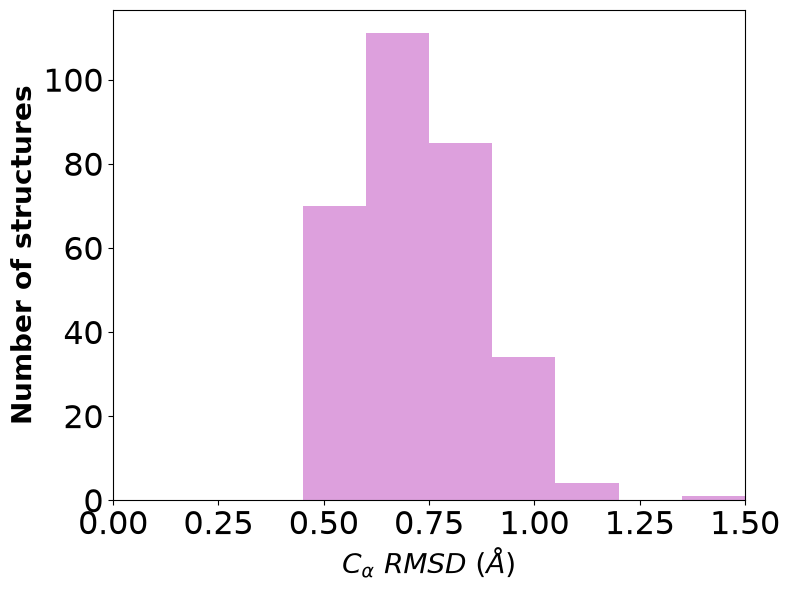

In [38]:
plt.figure(figsize=(8, 6))
#
plt.hist(
    data['rmsd'],
    bins = 10,
    range=(0, 1.5),
    color = 'plum'
)
#
plt.xlabel(r'$C_{\alpha}\ RMSD\ (\AA)$', fontsize=20, fontweight='bold')
plt.ylabel('Number of structures', fontsize=20, fontweight='bold')
plt.tick_params(axis='x', labelsize=23)
plt.tick_params(axis='y', labelsize=23)
plt.xlim(0, 1.5)
#
plt.tight_layout()
plt.show()

#### Dihedral angles

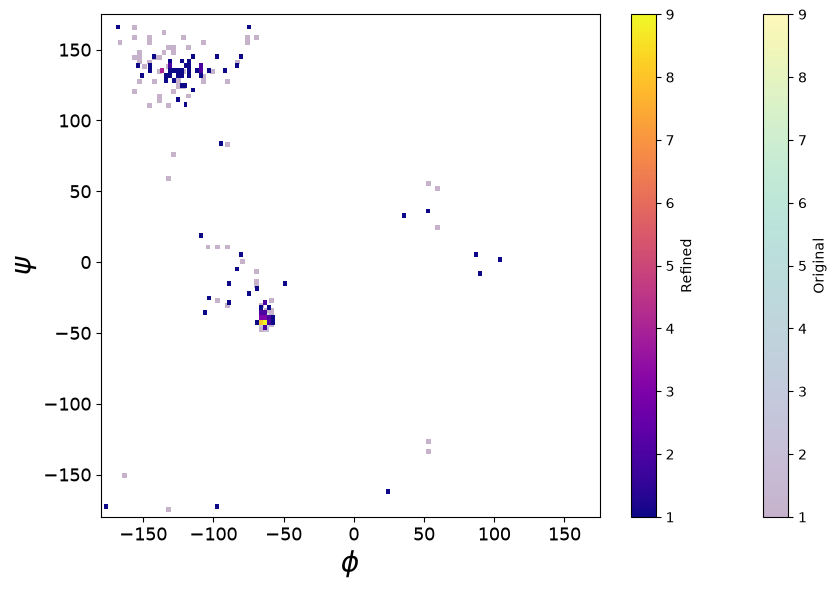

In [ ]:
# Plot Ramachandran plots
plt.figure(figsize=(9,6))
#
original = strucio.load_structure(data.loc[0, 'paths'])
phi_o, psi_o, omega = struc.dihedral_backbone(original)
phi_o = np.rad2deg(phi_o)[1:-1]
psi_o = np.rad2deg(psi_o)[1:-1]
_, _, _, im = plt.hist2d(
    phi_o,
    psi_o,
    bins=(100,100),
    cmap='viridis',
    alpha = 0.3,
    cmin=1
)
plt.colorbar(im, label='Original')
#
refined = strucio.load_structure(data.loc[1, 'paths'])
phi_r, psi_r, omega = struc.dihedral_backbone(refined)
phi_r = np.rad2deg(phi_r)[1:-1]
psi_r =  np.rad2deg(psi_r)[1:-1]
_, _, _, im2 = plt.hist2d(
    phi_r,
    psi_r,
    bins=(100,100),
    cmap='plasma',
    alpha = 1,
    cmin=1
)
plt.colorbar(im2, label='Refined')
#
plt.xlim(-180, 175)
plt.xlabel(r'$\phi$', fontsize=20, fontweight='bold')
plt.ylabel(r'$\psi$', fontsize=20, fontweight='bold')
plt.ylim(-180, 175)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()

In [79]:
def get_angles(
    row
):
    name = row['name']

    # Load original structure
    original = strucio.load_structure(f'{original_path}/{name}.pdb')
    phi_o, psi_o, omega = struc.dihedral_backbone(original) #calculate dihedral angles
    phi_o = np.rad2deg(phi_o)[1:-1] #rad -> deg, truncate nan
    psi_o = np.rad2deg(psi_o)[1:-1]
    
    # Load diffusion refined structure
    refined_pdb = f'{refined_path}/{name}_0.pdb'
    if Path(refined_pdb).exists():
        refined = strucio.load_structure(refined_pdb)
        phi_r, psi_r, omega = struc.dihedral_backbone(refined)
        phi_r = np.rad2deg(phi_r)[1:-1]
        psi_r =  np.rad2deg(psi_r)[1:-1]
    else:
        return None
    
    return (phi_o, psi_o, phi_r, psi_r)

data[["phi_o", "psi_o", "phi_r", "psi_r"]] = data.progress_apply( #type:ignore
    lambda row: get_angles(row),
    axis = 1,
    result_type = "expand"
) #type: ignore

100%|██████████████████████████████| 315/315 [00:04<00:00, 76.31it/s]


In [80]:
# calculate difference in dihedral angles
# + 180 to shift [-180, 180] -> [0, 360] change
# % 360 to get smallest rotation angle
# - 180 to shift back into [-180, 180]
data['phi_delta'] = (data['phi_o'] - data['phi_r'] + 180) % 360 - 180
data['psi_delta'] = (data['psi_o'] - data['psi_r'] + 180) % 360 - 180

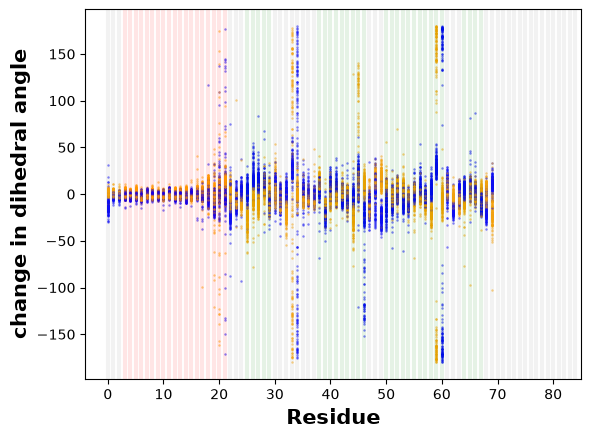

In [34]:
plt.figure()

structure_name = '5KPH'
for name in data['name']:
    if structure_name in name.split('/')[-1]:
        #get dihedral angles
        '''
        original = strucio.load_structure(f'{original_path}/{name}.pdb')
        phi_o, psi_o, omega = struc.dihedral_backbone(original)
        phi_o = np.rad2deg(phi_o)[1:-1]
        psi_o = np.rad2deg(psi_o)[1:-1]
        #
        refined_pdb = f'{refined_path}/{name}_0.pdb'
        if Path(refined_pdb).exists():
            refined = strucio.load_structure(refined_pdb)
            phi_r, psi_r, omega = struc.dihedral_backbone(refined)
            phi_r = np.rad2deg(phi_r)[1:-1]
            psi_r =  np.rad2deg(psi_r)[1:-1]
        else:
            continue
        '''
        phi_o = data[data['name'] == name]['phi_o'].values[0]
        phi_r = data[data['name'] == name]['phi_r'].values[0]
        psi_o = data[data['name'] == name]['psi_o'].values[0]
        psi_r = data[data['name'] == name]['psi_r'].values[0]

        if phi_o is not None:
        
            #phi angle changes
            plt.scatter(
                range(phi_o.size),
                (phi_o - phi_r + 180) % 360 - 180,
                color = 'blue',
                alpha = 0.5,
                linewidth=0,
                s = 3
                #label=r'$\phi$'
            )

            #psi angle changes
            plt.scatter(
                range(len(psi_o)),
                (psi_o - psi_r + 180) % 360 - 180,
                color = 'orange',
                alpha = 0.5,
                linewidth=0,
                s = 3
                #label=r'$\psi$'
            )

#annotate SS
original = strucio.load_structure(f'/wynton/home/rotation/geanhu/multi-state/data/base/{structure_name}.pdb')[0]
original_ss = struc.annotate_sse(original)
original_ss = [index for index, value in enumerate(original_ss) if value == 'c']
for index in original_ss:
    plt.axvline(
        x = index,
        color = 'gray',
        alpha = 0.1,
        lw = 3
    )
#
original_ss = struc.annotate_sse(original)
original_ss = [index for index, value in enumerate(original_ss) if value == 'a']
for index in original_ss:
    plt.axvline(
        x = index,
        color = 'red',
        alpha = 0.1,
        lw = 3
    )
#
original_ss = struc.annotate_sse(original)
original_ss = [index for index, value in enumerate(original_ss) if value == 'b']
for index in original_ss:
    plt.axvline(
        x = index,
        color = 'green',
        alpha = 0.1,
        lw = 3
    )

#axes
plt.ylabel(r'change in dihedral angle', fontsize=15, fontweight='bold')
#plt.ylim(-180, 180)
plt.xlabel('Residue', fontsize=15, fontweight='bold')
plt.show()

In [43]:
data = data.dropna()
data = data[data['name'].str.contains('5KPE')]
np.vstack([arr for arr in data['phi_delta']]).shape

(152, 106)

In [81]:
# Write structure with std dev change
structure_name = '5KPE'

# Get std dev of torsion angle changes
data = data.dropna()
data = data[data['name'].str.contains(structure_name)]
phi_d_std = np.std(np.vstack([arr for arr in data['phi_delta']]), axis=0)
psi_d_std = np.std(np.vstack([arr for arr in data['psi_delta']]), axis=0)
angle_d_std = np.max([phi_d_std, psi_d_std], axis=0) #take max between phi and psi angle change

# Load original structure
original = strucio.load_structure(f'/wynton/home/rotation/geanhu/multi-state/data/base/{structure_name}.pdb', extra_fields=['b_factor'])[0] #type:ignore

# Load, impute 0
atom_values = np.zeros(int(struc.get_residue_count(original)))
atom_values[:len(angle_d_std)] = angle_d_std

# Annotate
original.b_factor = [
    atom_values[res_id - 1] #since res # is 1-indexed
    for res_id in original.res_id
]

# save
strucio.save_structure(f'/wynton/home/rotation/geanhu/multi-state/data/misc/{structure_name}_angle-delta-std.pdb', original)

/wynton/home/rotation/geanhu/.conda/envs/analysis/lib/python3.14/site-packages/biotite/structure/io/pdb/file.py:615: DeprecationWarning: The chararray class is deprecated and will be removed in a future release. Use an ndarray with a string or bytes dtype instead.
  record = np.char.array(np.where(array.hetero, "HETATM", "ATOM"))


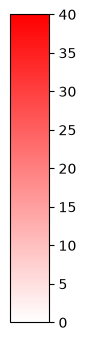

In [86]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# colorbar for pymol structure
norm = mcolors.Normalize(vmin=0, vmax=40)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_red",
    ["white", "red"]
)

fig, ax = plt.subplots(figsize=(0.5, 4))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(
    sm,
    cax = ax,
    orientation="vertical"
)
plt.show()

#### Effect of increasing diffuser.T

In [161]:
data = {
    't': [0, 50, 100, 150, 200],
    'paths': [
        '/wynton/home/rotation/geanhu/multi-state/data/string-sampling/end-states/5KPE_8_8_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE-5KPH/pdb/5KPE_8_8_0_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE_higher-T/100_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE_higher-T/150_0.pdb',
        '/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE_higher-T/200_0.pdb'
    ]
}
data = pd.DataFrame(data)

In [67]:
def find_rmsd(name):
    # load structure files
    original_file = data.loc[0, 'paths']
    if Path(original_file).exists():
        original_struc = strucio.load_structure(
            original_file
        )
    else:
        return None
    refined_file = name
    if Path(refined_file).exists():
        refined_struc = strucio.load_structure(
            refined_file
        )
    else:
        return None

    # superimpose / align
    refined_aligned, transform = struc.superimpose(
        original_struc,
        refined_struc,
        atom_mask=(struc.filter_peptide_backbone(refined_struc))
    )

    # get C_alpha rmsd
    rmsd = struc.rmsd(
        original_struc[original_struc.atom_name == "CA"],
        refined_aligned[refined_aligned.atom_name == "CA"]
    )
    return rmsd

data['rmsd'] = data['paths'].apply(
    lambda name: find_rmsd(name)
)

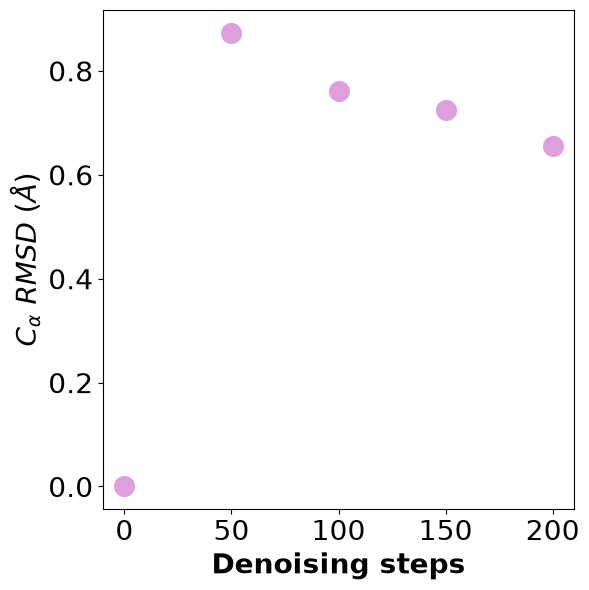

In [ ]:
plt.figure(figsize=(6, 6))
#
plt.scatter(
    data['t'].astype(int),
    data['rmsd'],
    color = 'plum',
    s=200
)
#
plt.xlabel('Denoising steps', fontsize=20, fontweight='bold')
plt.ylabel(r'$C_{\alpha}\ RMSD\ (\AA)$', fontsize=20, fontweight='bold')
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
#
plt.tight_layout()
plt.show()

#### Beta sheet register shift

In [6]:
# manually indicate residue ranges for strands
b_residues = {
    '5KPE': [
        (54, 66),
        (68, 80),
        (82, 96),
        (98, 106)
    ], #1-indexed (inclusive, exclusive)
    '5KPH': [
        (26, 34),
        (37, 47),
        (49, 61),
        (63, 71)
    ]
}

In [133]:
# determine register shift for beta sheet strands
def triplets_to_matrix(triplets, structure):
    struc_len = len(struc.get_residues(structure)[1])
    bond_matrix = np.zeros((struc_len + 1, struc_len + 1)) #make 1-indexed
    for triplet in triplets:
        donor = triplet[0]
        donor_res = int(structure[donor].res_id)
        #
        acceptor = triplet[2]
        acceptor_res = int(structure[acceptor].res_id)
        #
        bond_matrix[donor_res, acceptor_res] = 1
        bond_matrix[acceptor_res, donor_res] = 1
    return bond_matrix 

def find_register(matrix):
    bonds = np.argwhere(matrix == 1)
    registers = [
        np.abs(coord[1] + coord[0]) 
        for coord in bonds
    ]
    if len(registers) > 0:
        assert np.std(registers) <= 0.5, bonds
        return float(np.median(registers))
    else:
        return None

def register_shift(
    row
):
    name = row['name']
    # paths
    pdb1 = f'{original_path}/{name}.pdb'
    pdb2 = f'{refined_path}/{name}_0.pdb'
    structure_name = name[:4]

    # open structures, backbone atoms
    pdb1_struc = strucio.load_structure(pdb1, include_bonds=True)
    #
    pdb2_struc = strucio.load_structure(pdb2, include_bonds=True)
    # add hydrogens
    pdb1_struc.set_annotation(
        "charge",
        hydride.estimate_amino_acid_charges(pdb1_struc, ph=7.4)
    )
    pdb1_struc, _ = hydride.add_hydrogen(pdb1_struc)
    pdb1_struc.coord = hydride.relax_hydrogen(pdb1_struc) #type: ignore
    #
    pdb2_struc.set_annotation(
        "charge",
        hydride.estimate_amino_acid_charges(pdb2_struc, ph=7.4)
    )
    pdb2_struc, _ = hydride.add_hydrogen(pdb2_struc)
    pdb2_struc.coord = hydride.relax_hydrogen(pdb2_struc) #type: ignore

    # determine H bonding | cutoff_dist 2.5, cutoff_angle 120
    triplets_pdb1 = struc.hbond(pdb1_struc) #[donor, h, acceptor]
    triplets_pdb2 = struc.hbond(pdb2_struc)

    # reorganize hydrogen bonds by residue index
    hbonds_pdb1 = triplets_to_matrix(triplets_pdb1, pdb1_struc)
    hbonds_pdb2 = triplets_to_matrix(triplets_pdb2, pdb2_struc)

    # iterate each adjacent strand pairing
    shifts = []
    for pairing in [
        (0, 1),
        (1, 2),
        (2, 3)
    ]:
        # get residue ranges of adjacent strands
        a_start, a_end = b_residues[name[:4]][pairing[0]]
        b_start, b_end = b_residues[name[:4]][pairing[1]]
        hbonds_pair1 = hbonds_pdb1[a_start:a_end, b_start:b_end]
        hbonds_pair2 = hbonds_pdb2[a_start:a_end, b_start:b_end]

        # register
        register1 = find_register(hbonds_pair1)
        register2 = find_register(hbonds_pair2)
        if register1 and register2:
            shift = register2 - register1
            shifts.append(shift)
        else:
            shifts.append(None)
    
    return shifts[0], shifts[1], shifts[2]
        

In [134]:
data[['shift1', 'shift2', 'shift3']] = data.progress_apply(
    register_shift,
    axis = 1,
    result_type='expand'
)

100%|████████████████████████████████████████| 315/315 [00:34<00:00,  9.13it/s]


In [135]:
# plot register shifts
for column in ['shift1', 'shift2', 'shift3']:
    print(column)
    shift, count = np.unique(data[column], return_counts=True)
    for shift, count in zip(shift, count):
        print(f'Register shift {shift}: {count} structures')

shift1
Register shift -0.5: 9 structures
Register shift 0.0: 305 structures
Register shift 0.5: 1 structures
shift2
Register shift 0.0: 313 structures
Register shift nan: 2 structures
shift3
Register shift -1.0: 1 structures
Register shift -0.5: 2 structures
Register shift 0.0: 312 structures


In [136]:
# list of backbones that have shifts and/or problems
data[
    (data['shift1'] != 0) | (data['shift2'] != 0) | (data['shift3'] != 0)
]

,name,rmsd,shift1,shift2,shift3
178,5KPH_6_2_4,1.470422,0.0,0.0,-0.5
268,5KPH_6_2_7,0.700409,-0.5,0.0,0.0
25,5KPH_8_2_1,0.948819,-0.5,0.0,-0.5
296,5KPH_8_2_4,0.965228,-0.5,0.0,-1.0
176,5KPH_8_2_5,0.960506,-0.5,0.0,0.0
108,5KPH_8_4_1,0.854080,0.5,0.0,0.0
9,5KPH_8_4_5,1.187466,0.0,NaN,0.0
94,5KPH_8_4_8,0.774285,-0.5,0.0,0.0
16,5KPH_8_4_9,0.924916,-0.5,0.0,0.0
305,5KPH_8_6_7,0.922565,-0.5,0.0,0.0


#### Curvature

In [ ]:
def calc_curvature(structure, name):
    ranges = b_residues[name]
    curvatures = []
    for res_range in ranges:
        for i in range(res_range[0] + 2, res_range[1] - 2): #5 res windows
            # get atom coordinates
            left_atom = structure[(structure.res_id == i - 2) & (structure.atom_name == "CA")].coord
            middle_atom = structure[(structure.res_id == i) & (structure.atom_name == "CA")].coord
            right_atom = structure[(structure.res_id == i + 2) & (structure.atom_name == "CA")].coord

            # define vectors
            vector_left = middle_atom - left_atom
            vector_right = middle_atom - right_atom

            # angle between
            angle = np.dot(vector_left.reshape(3,), vector_right.reshape(3,))
            angle /= (np.linalg.norm(vector_left) * np.linalg.norm(vector_right))
            angle = np.clip(angle, -1, 1)
            angle = np.degrees(np.arccos(angle))
            #angle = np.min([angle, 180.0 - angle])
            angle = 180 - angle
            curvatures.append(angle)
    return curvatures

def get_curvature(
    row
):
    name = row['name']
    # paths
    pdb1 = f'{original_path}/{name}.pdb'
    pdb2 = f'{refined_path}/{name}_0.pdb'
    structure_name = name[:4]

    # open structures
    pdb1_struc = strucio.load_structure(pdb1)
    #
    pdb2_struc = strucio.load_structure(pdb2)

    curvature1 = calc_curvature(pdb1_struc, name[:4])
    curvature2 = calc_curvature(pdb2_struc, name[:4])
    
    #mean median max
    return np.mean(curvature1), np.median(curvature1), np.max(curvature1), np.mean(curvature2), np.median(curvature2), np.max(curvature2), np.mean(np.array(curvature2) - np.array(curvature1)), np.min(np.array(curvature2) - np.array(curvature1))

In [ ]:
data[['mean_c', 'med_c', 'max_c', 'mean_c_ref', 'med_c_ref', 'max_c_ref', 'mean_delta', 'max_delta', 'max_delta_res']] = data.progress_apply(
    get_curvature,
    axis = 1,
    result_type='expand'
) #type: ignore

100%|███████████████████████████████████████████████| 315/315 [00:04<00:00, 63.75it/s]


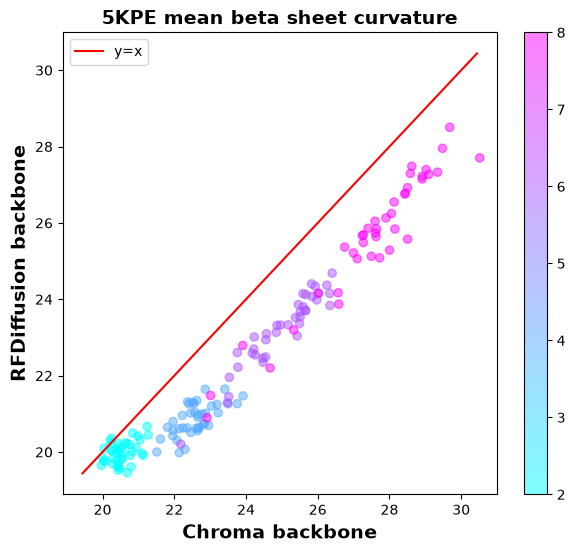

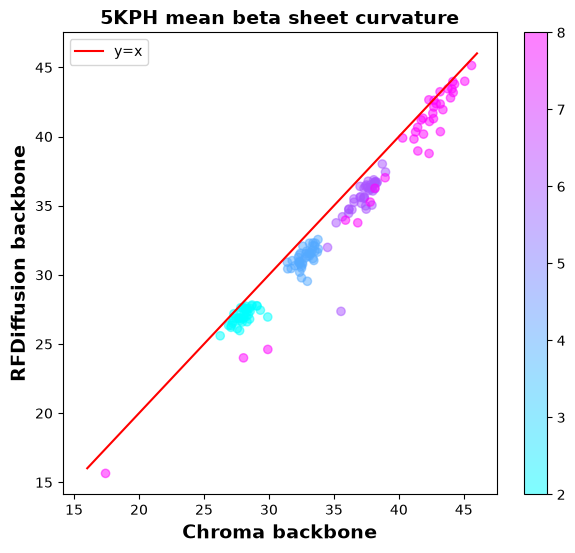

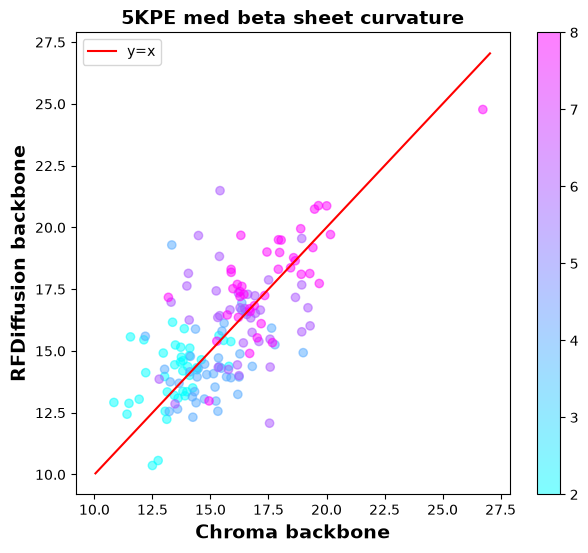

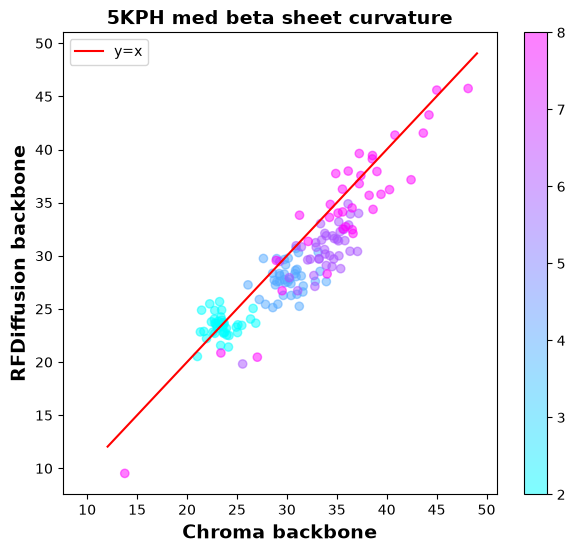

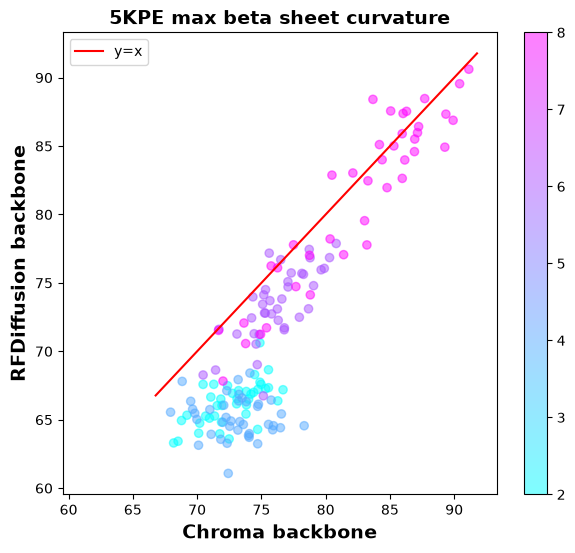

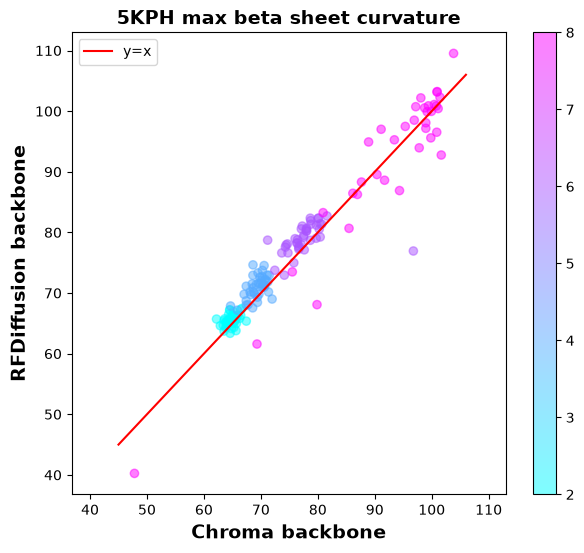

In [52]:
for column in ['mean_c', 'med_c', 'max_c']:
    for structure in ['5KPE', '5KPH']:
        graph_data = data[data['structure'] == structure] #type: ignore
        plt.figure(figsize=(7, 6))
        plt.title(f'{structure} {column[:-2]} beta sheet curvature', fontsize=14, fontweight='bold')
        plt.scatter(
            graph_data[column],
            graph_data[f'{column}_ref'],
            # color by RMSD constraint
            c = graph_data['rmsd_constraint'],
            cmap = 'cool',
            alpha = 0.5
        )
        plt.colorbar()
        plt.xlabel('Chroma backbone', fontsize=14, fontweight='bold')
        plt.ylabel('RFDiffusion backbone', fontsize=14, fontweight='bold')
        plt.plot(
            np.arange(plt.xlim()[0], plt.xlim()[1]),
            np.arange(plt.xlim()[0], plt.xlim()[1]),
            c = 'red',
            label = 'y=x'
        )
        plt.legend()
        plt.xlim(plt.ylim())
        plt.show()

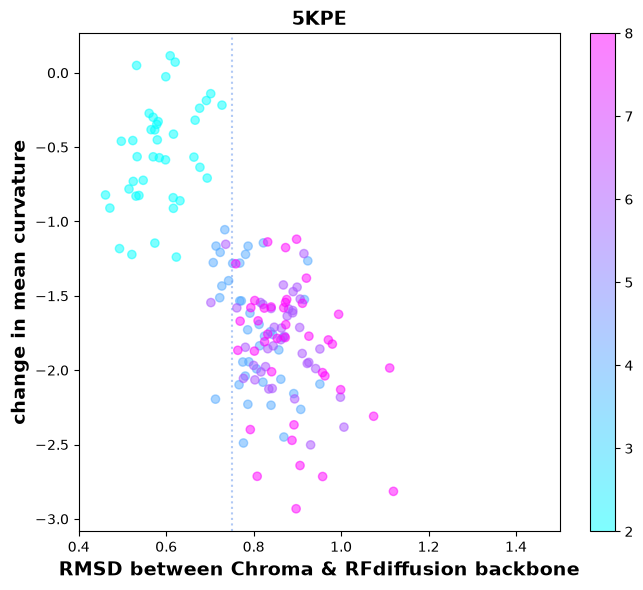

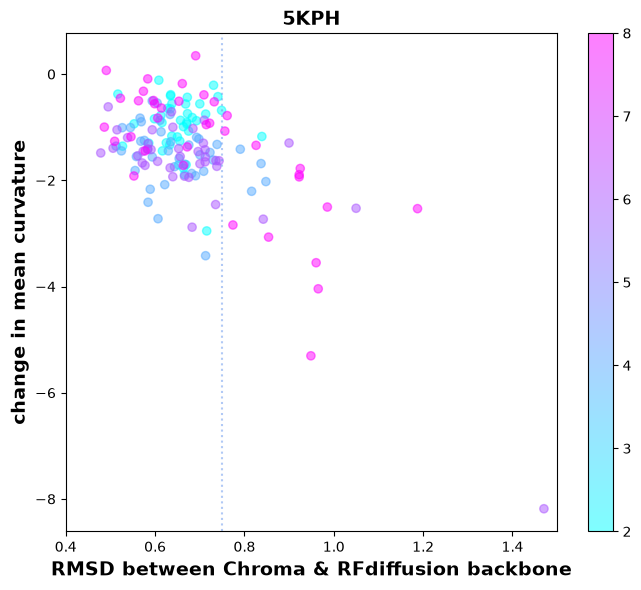

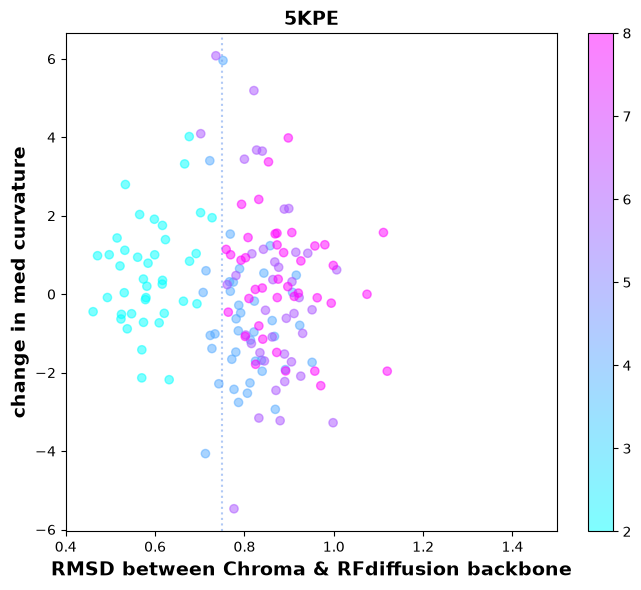

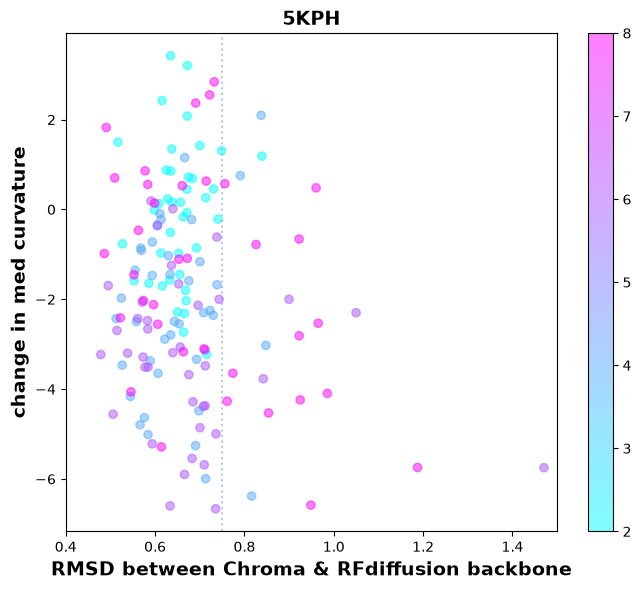

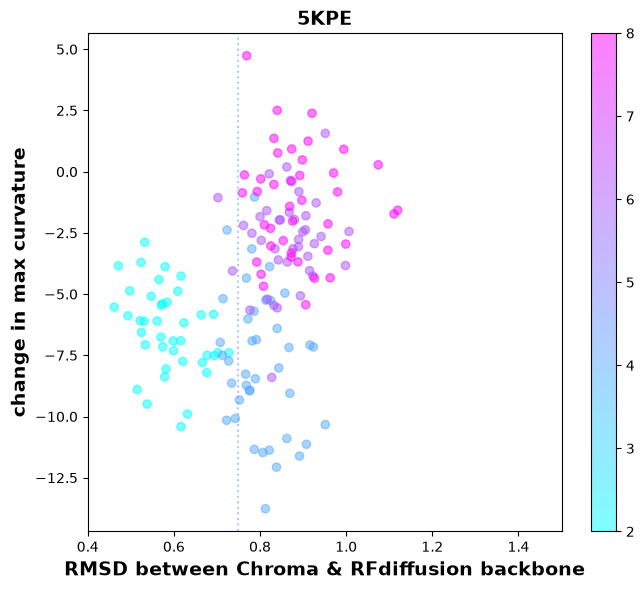

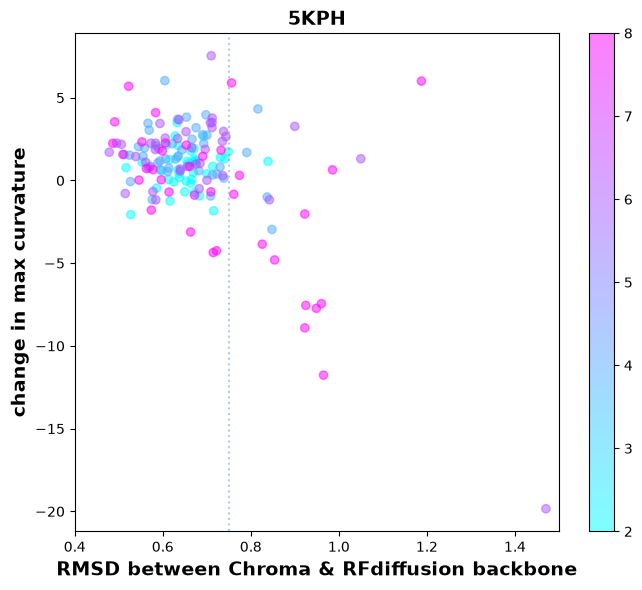

In [53]:
for column in ['mean_c', 'med_c', 'max_c']:
    for structure in ['5KPE', '5KPH']:
        graph_data = data[data['structure'] == structure] #type: ignore
        plt.figure(figsize=(7, 6))

        # plot
        plt.scatter(
            graph_data['rmsd'],
            graph_data[f'{column}_ref'] - graph_data[f'{column}'],
            c = graph_data['rmsd_constraint'],
            cmap = 'cool',
            alpha = 0.5
        )
        plt.colorbar()

        # cutoffs
        # 0.75
        plt.axvline(
            x = 0.75,
            linestyle=':',
            alpha = 0.5,
            c = 'cornflowerblue'
        )

        # labels
        plt.title(f'{structure}', fontsize=14, fontweight='bold')
        plt.xlabel('RMSD between Chroma & RFdiffusion backbone', fontsize=14, fontweight='bold')
        plt.xlim(0.4, 1.5)
        plt.ylabel(f'change in {column[:-2]} curvature', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

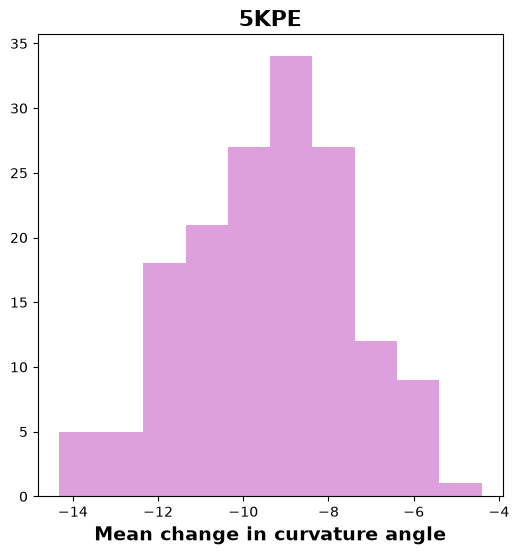

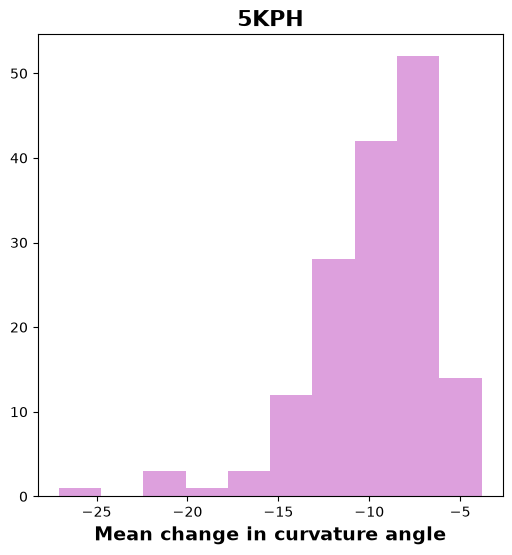

In [65]:
for structure in ['5KPE', '5KPH']:
    graph_data = data[data['structure'] == structure] #type: ignore
    plt.figure(figsize=(6, 6))
    plt.hist(
        graph_data['max_delta'],
        color = 'plum'
    )
    plt.xlabel('Mean change in curvature angle', fontsize=14, fontweight='bold')
    plt.title(structure, fontsize=16, fontweight='bold')
    plt.show()

In [55]:
data.to_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/backbones.csv')

In [66]:
name = '5KPE_8_2_5'
# paths
pdb1 = f'{original_path}/{name}.pdb'
pdb2 = f'{refined_path}/{name}_0.pdb'
structure_name = name[:4]

# open structures
pdb1_struc = strucio.load_structure(pdb1)
#
pdb2_struc = strucio.load_structure(pdb2)

# curvatures
curvature1 = calc_curvature(pdb1_struc, name[:4])
curvature2 = calc_curvature(pdb2_struc, name[:4])
curvature = np.array(curvature2) - np.array(curvature1)

In [72]:
# save structures
values = {
    res_id: 0 for res_id in range(1, 109)
}
curvature_gen = (float(value) for value in curvature)
ranges = [
    (54, 66),
    (68, 80),
    (82, 96),
    (98, 106)
]
for res_range in ranges:
    for idx in range(res_range[0] + 2, res_range[1] - 2):
        values[idx] = next(curvature_gen)

pdb1_struc.add_annotation("b_factor", float)
pdb1_struc.b_factor = np.array(
    [values[r] for r in pdb1_struc.res_id],
    dtype=float
)
strucio.save_structure('5KPE_8_2_5_delta-curvature.pdb', pdb1_struc)